#Kavish Nag
#24070126085
#AIML B1

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import pairwise_distances
from sklearn.manifold import MDS,TSNE
from sklearn.datasets import load_iris

In [13]:
iris=load_iris(as_frame=True)
X = iris.data
y = iris.target
target_names=iris.target_names

X.shape

(150, 4)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_scaled.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,-0.900681,1.019004,-1.340227,-1.315444
1,-1.143017,-0.131979,-1.340227,-1.315444
2,-1.385353,0.328414,-1.397064,-1.315444
3,-1.506521,0.098217,-1.283389,-1.315444
4,-1.021849,1.249201,-1.340227,-1.315444


In [15]:
mds = MDS(n_components=2, random_state=42)
X_mds = mds.fit_transform(X_scaled)

In [16]:
df = pd.DataFrame(X_mds, columns=['MDS1', 'MDS2'])
df['Target'] = y

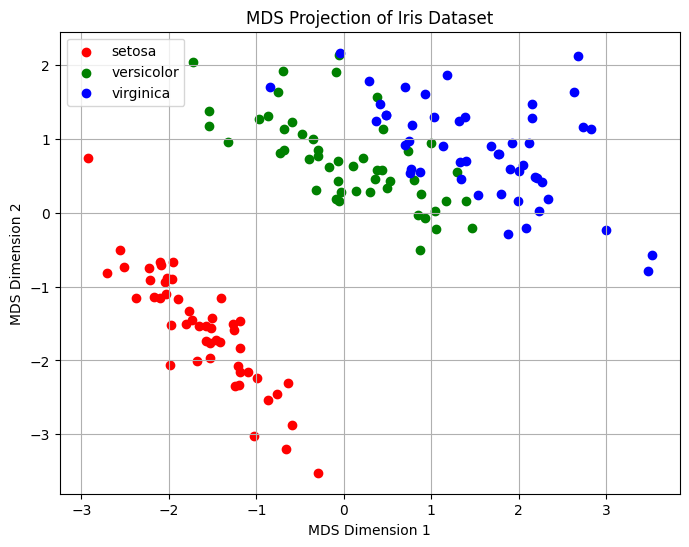

In [17]:
plt.figure(figsize=(8, 6))

colors = ['red', 'green', 'blue']
for i, target_name in enumerate(target_names):
    plt.scatter(
        df[df['Target'] == i]['MDS1'],
        df[df['Target'] == i]['MDS2'],
        label=target_name,
        color=colors[i]
    )

plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('MDS Projection of Iris Dataset')
plt.legend()
plt.grid()

plt.show()

In [18]:
# Perform Non-Metric MDS (MMDS)
mmds = MDS(n_components=2, metric=False, random_state=42)
X_mmds = mmds.fit_transform(X_scaled)

# Create a DataFrame for MMDS results
df_mmds = pd.DataFrame(X_mmds, columns=['MMDS1', 'MMDS2'])
df_mmds['Target'] = y

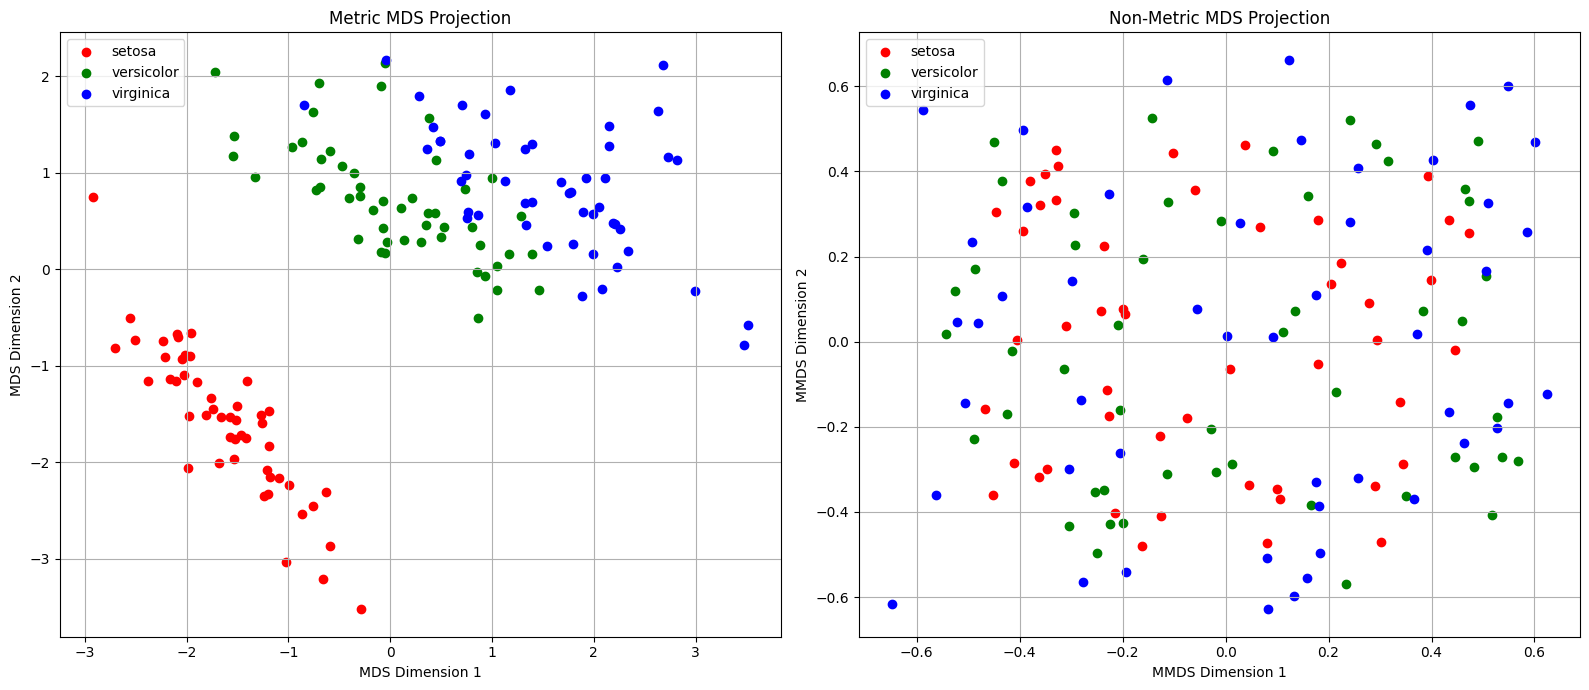

In [19]:
plt.figure(figsize=(16, 7))

# Plot for Metric MDS
plt.subplot(1, 2, 1)
colors = ['red', 'green', 'blue']
for i, target_name in enumerate(target_names):
    plt.scatter(
        df[df['Target'] == i]['MDS1'],
        df[df['Target'] == i]['MDS2'],
        label=target_name,
        color=colors[i]
    )
plt.xlabel('MDS Dimension 1')
plt.ylabel('MDS Dimension 2')
plt.title('Metric MDS Projection')
plt.legend()
plt.grid()

# Plot for Non-Metric MDS
plt.subplot(1, 2, 2)
for i, target_name in enumerate(target_names):
    plt.scatter(
        df_mmds[df_mmds['Target'] == i]['MMDS1'],
        df_mmds[df_mmds['Target'] == i]['MMDS2'],
        label=target_name,
        color=colors[i]
    )
plt.xlabel('MMDS Dimension 1')
plt.ylabel('MMDS Dimension 2')
plt.title('Non-Metric MDS Projection')
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()